# Progetto MIGA 2025/2026 — Sistema di Raccomandazione e Sentiment Analysis
## Notebook unico — Dataset Amazon Reviews 2023, categoria Movies_and_TV (Film & TV)

Questo notebook raccoglie l'intero progetto di **livello avanzato** in un solo file, in tre parti:

1. **Parte 1 — Progetto Base**: Collaborative Filtering (K-NN ottimale, filling, K-Means + cosine, top-N, Matrix Factorization).
2. **Parte 2 — Progetto Intermedio**: Content-Based (NLP, embedding TF-IDF e transformer, K-NN per utente, confronti critici).
3. **Parte 3 — Progetto Avanzato**: Sentiment Analysis (classificatori scikit-learn + bonus LLM).

**Come eseguire (Google Colab):** attiva la **GPU** (Runtime > Cambia tipo di runtime > T4), esegui la cella di installazione **una sola volta**, poi tutte le celle in ordine dall'alto verso il basso. La categoria si cambia nelle celle di configurazione di ciascuna parte (`CATEGORY`).

> Nota: Movies_and_TV e' enorme, quindi i dati vengono caricati **in streaming** su un campione. Le tre parti caricano i dati in modo indipendente: se vuoi puoi abbassare `MAX_REVIEWS` per andare piu veloce in fase di test.

## Installazione (eseguire una sola volta)

In [26]:
!pip -q install scikit-surprise datasets sentence-transformers transformers nltk scikit-learn pandas numpy matplotlib seaborn

---
# PARTE 1 — Progetto Base (Collaborative Filtering)

## 0. Setup ambiente

`scikit-surprise` su Colab a volte richiede una versione di NumPy compatibile: se l'import fallisce, riavvia il runtime dopo l'installazione (Runtime > Restart).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, KNNWithMeans, KNNBasic, SVD, accuracy
from surprise.model_selection import GridSearchCV, train_test_split, cross_validate

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## Configurazione

- `CATEGORY`: categoria merceologica da analizzare (default consigliato: `All_Beauty`).
- `MIN_USER_RATINGS` / `MIN_ITEM_RATINGS`: soglie di filtro per ridurre la sparsita e rendere il Collaborative Filtering significativo e computazionalmente trattabile (discutere questa scelta nel report: trade-off copertura vs densita / cold-start).

In [28]:
CATEGORY = "Movies_and_TV"   # categoria Film & TV
MIN_USER_RATINGS = 5         # tieni utenti con almeno N recensioni
MIN_ITEM_RATINGS = 5         # tieni item con almeno N recensioni
RATING_SCALE = (1, 5)
TOP_N = 10                   # quante raccomandazioni per utente

# Movies_and_TV e' enorme: lavoriamo su un campione in streaming per non saturare la RAM di Colab
STREAMING = True
MAX_REVIEWS = 800000         # dimensione del campione iniziale (alza se hai RAM)
# Il "core": teniamo gli utenti e gli item piu attivi per avere una matrice densa e trattabile
USERS_CAP = 3000
ITEMS_CAP = 1500

## Step 0 — Caricamento dati (solo user reviews)

Per il Progetto Base si usa **solo il file delle recensioni** (`user reviews`). Carichiamo da HuggingFace la config `raw_review_<CATEGORY>`.

In [29]:
from datasets import load_dataset

def load_reviews(category, max_rows=MAX_REVIEWS, streaming=STREAMING):
    # Le nuove versioni di datasets non eseguono lo script del repo:
    # leggiamo direttamente il file .jsonl grezzo col builder "json".
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=streaming)
    if streaming:
        ds = ds.shuffle(seed=42, buffer_size=50000)
        rows = []
        for ex in ds:
            rows.append(ex)
            if len(rows) >= max_rows:
                break
        df_ = pd.DataFrame(rows)
    else:
        df_ = ds.to_pandas()
    # nel jsonl grezzo i campi si chiamano sort_timestamp / helpful_votes
    return df_.rename(columns={"sort_timestamp": "timestamp", "helpful_votes": "helpful_vote"})

df = load_reviews(CATEGORY)
print("Shape campione:", df.shape)
df.head(3)

Shape campione: (800000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Fun MOvie,A very good car movie. Loved the humor and th...,[],B00MFDMM3I,B00MFDMM3I,AHV3V3SLT35QHQX3NQOFUDBNV2RQ,1408671919000,1,True
1,5.0,Amazing!!!,I was not prepared for the magic of this movie...,[],B0098VYCCE,B0098VYCCE,AGPFPRUBXXX65L6NCPFRYOC33JZQ,1349182789000,1,True
2,5.0,amazing,amazing and great patriotic movie. Bacon is a...,[],B009M8Q3O8,B009M8Q3O8,AGJD7SRDILE7BF3VKDRXI6B7OOPQ,1461105792000,0,True


In [30]:
# Teniamo solo le colonne utili per il CF + qualche colonna per la EDA
cols = ["rating", "title", "text", "asin", "parent_asin", "user_id",
        "timestamp", "verified_purchase", "helpful_vote"]
df = df[[c for c in cols if c in df.columns]].copy()

# Usiamo parent_asin come identificatore di item (la traccia nota che asin storici = parent_asin)ù
#in questa maniera film di versioni diverse vengono identificate dallo stesso asin
df["item_id"] = df["parent_asin"].fillna(df["asin"])
df = df.dropna(subset=["user_id", "item_id", "rating"])
df["rating"] = df["rating"].astype(float)
print("Shape pulita:", df.shape)

Shape pulita: (800000, 10)


In [31]:
# Tabella 1.1 — Statistiche di base del dataset
stats_base = pd.DataFrame({
    "Metrica": ["Utenti unici", "Film unici (parent_asin)", "Recensioni totali"],
    "Valore": [
        df["user_id"].nunique(),
        df["item_id"].nunique(),
        len(df)
    ]
})
stats_base["Valore"] = stats_base["Valore"].apply(lambda x: f"{x:,}")
print("Tabella 1.1 — Statistiche di base (corpus originale)")
display(stats_base)

Tabella 1.1 — Statistiche di base (corpus originale)


,Metrica,Valore
0,Utenti unici,"134,475"
1,Film unici (parent_asin),"188,506"
2,Recensioni totali,"800,000"


## Step 1 — Analisi Esplorativa (EDA)

Statistiche descrittive, distribuzioni e analisi di correlazione.

In [32]:
print("Recensioni totali :", len(df))
print("Utenti unici       :", df["user_id"].nunique())
print("Item unici         :", df["item_id"].nunique())
print("Periodo            :", pd.to_datetime(df["timestamp"], unit="ms").min(),
      "->", pd.to_datetime(df["timestamp"], unit="ms").max())
display(df["rating"].describe())

Recensioni totali : 800000
Utenti unici       : 134475
Item unici         : 188506
Periodo            : 1998-07-08 23:29:46 -> 2023-03-19 20:22:56.754000


,rating
count,800000.000000
mean,4.237800
std,1.203481
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


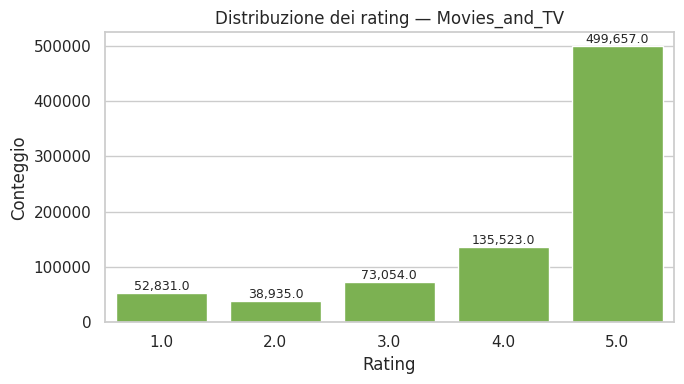

Rating medio: 4.238
% rating >= 4: 79.4 %  (tipico forte sbilanciamento positivo)


In [33]:
# Distribuzione dei rating
plt.figure(figsize=(7,4))
ax = sns.countplot(x="rating", data=df, color="#7AC142")
ax.set_title(f"Distribuzione dei rating — {CATEGORY}")
ax.set_xlabel("Rating"); ax.set_ylabel("Conteggio")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

print("Rating medio:", round(df["rating"].mean(), 3))
print("% rating >= 4:", round((df["rating"]>=4).mean()*100, 1), "%  (tipico forte sbilanciamento positivo)")

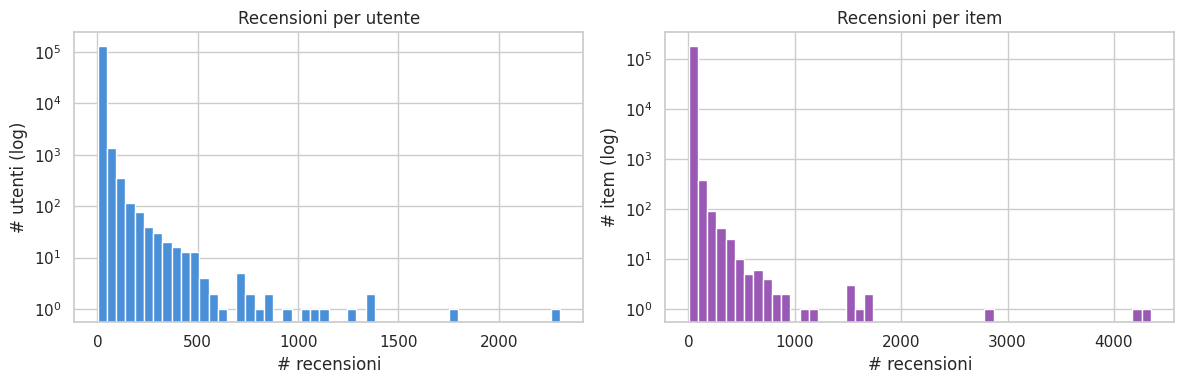

Sparsita della matrice utente-item: 99.9968%  (vicino al 100% = molto sparsa)


In [34]:
# Quante recensioni per utente e per item (long tail tipica)
rpu = df.groupby("user_id").size()
rpi = df.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(rpu, bins=50, color="#4A90D9"); axes[0].set_yscale("log")
axes[0].set_title("Recensioni per utente"); axes[0].set_xlabel("# recensioni"); axes[0].set_ylabel("# utenti (log)")
axes[1].hist(rpi, bins=50, color="#9B59B6"); axes[1].set_yscale("log")
axes[1].set_title("Recensioni per item"); axes[1].set_xlabel("# recensioni"); axes[1].set_ylabel("# item (log)")
plt.tight_layout(); plt.show()

n_pairs = df["user_id"].nunique() * df["item_id"].nunique()
sparsity = 1 - len(df)/n_pairs
print(f"Sparsita della matrice utente-item: {sparsity*100:.4f}%  (vicino al 100% = molto sparsa)")

In [35]:
# Verified purchase e helpful vote
if "verified_purchase" in df.columns:
    print(df["verified_purchase"].value_counts(normalize=True).rename("quota"))
if "helpful_vote" in df.columns:
    print("\nHelpful vote — describe:")
    display(df["helpful_vote"].describe())

verified_purchase
True     0.803203
False    0.196797
Name: quota, dtype: float64

Helpful vote — describe:


,helpful_vote
count,800000.000000
mean,1.203811
std,10.812403
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2162.000000


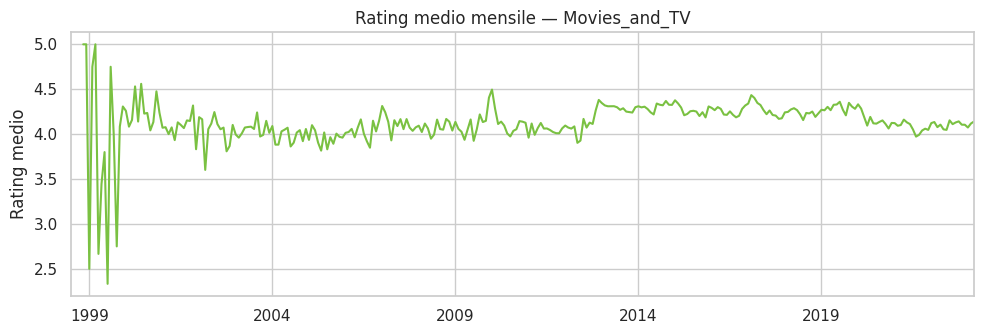

In [36]:
# Andamento del rating medio nel tempo
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
monthly = df.set_index("date")["rating"].resample("ME").mean()
plt.figure(figsize=(10,3.5))
monthly.plot(color="#7AC142")
plt.title(f"Rating medio mensile — {CATEGORY}"); plt.ylabel("Rating medio"); plt.xlabel("")
plt.tight_layout(); plt.show()

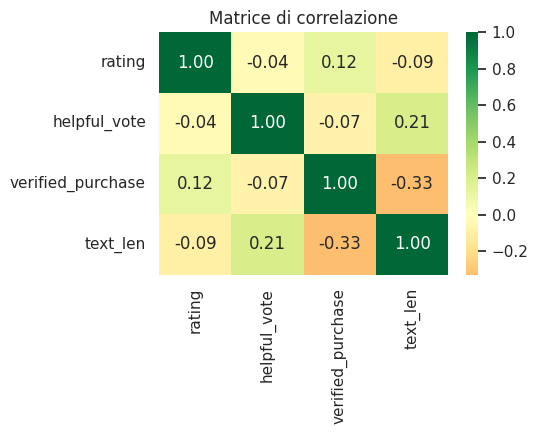

,rating,helpful_vote,verified_purchase,text_len
rating,1.000000,-0.037492,0.120298,-0.094738
helpful_vote,-0.037492,1.000000,-0.071213,0.206380
verified_purchase,0.120298,-0.071213,1.000000,-0.328751
text_len,-0.094738,0.206380,-0.328751,1.000000


In [37]:
# Analisi di correlazione tra variabili numeriche
df["text_len"] = df["text"].fillna("").str.len()
num_cols = [c for c in ["rating", "helpful_vote", "verified_purchase", "text_len"] if c in df.columns]
corr_df = df[num_cols].copy()
if "verified_purchase" in corr_df:
    corr_df["verified_purchase"] = corr_df["verified_purchase"].astype(int)
corr = corr_df.corr()
plt.figure(figsize=(5.5,4.5))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Matrice di correlazione")
plt.tight_layout(); plt.show()
display(corr)

### Filtro di densita

Per rendere il CF significativo (e la matrice trattabile) teniamo solo utenti e item con un numero minimo di interazioni. Iteriamo il filtro finche stabile, perche rimuovere utenti puo far scendere item sotto soglia e viceversa.

In [38]:
# Sezione 1.3.2 — Analisi dei duplicati
n_prima = len(df)
dup_mask = df.duplicated(subset=["user_id", "item_id"], keep=False)
n_duplicati = dup_mask.sum()

# Deduplicazione: tieni l'ultima recensione per coppia (user, item)
df = df.sort_values("timestamp").drop_duplicates(["user_id", "item_id"], keep="last")
n_dopo = len(df)

tab_dup = pd.DataFrame({
    "Parametro": ["Recensioni iniziali", "Recensioni dopo deduplicazione", "Duplicati rimossi"],
    "Valore": [f"{n_prima:,}", f"{n_dopo:,}", f"{n_prima - n_dopo:,}"]
})
print(f"Duplicati trovati (coppie ripetute): {n_duplicati:,} ({n_duplicati/n_prima*100:.2f}% del totale)")
print("\nTabella 1.2 — Statistiche deduplicazione")
display(tab_dup)

Duplicati trovati (coppie ripetute): 4,002 (0.50% del totale)

Tabella 1.2 — Statistiche deduplicazione


,Parametro,Valore
0,Recensioni iniziali,"800,000"
1,Recensioni dopo deduplicazione,"797,999"
2,Duplicati rimossi,"2,001"


Sparsità matrice originale: 99.9969%  (prossima al 100%)


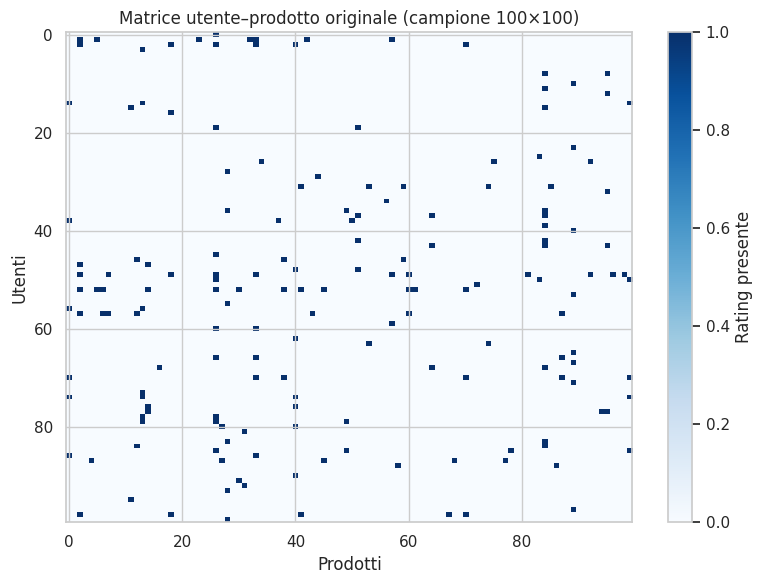

Nota: la quasi totalità delle celle è vuota → sparsità prossima al 100%.


In [39]:
# Sezione 1.3.3 — Sparsità della matrice originale
n_u_orig = df["user_id"].nunique()
n_i_orig = df["item_id"].nunique()
sparsita_orig = 1 - len(df) / (n_u_orig * n_i_orig)
print(f"Sparsità matrice originale: {sparsita_orig:.4%}  (prossima al 100%)")

# Visualizzazione: campione dei 100 utenti e 100 film più attivi
top_u_viz = df.groupby("user_id").size().sort_values(ascending=False).head(100).index
top_i_viz = df.groupby("item_id").size().sort_values(ascending=False).head(100).index
sample = df[df["user_id"].isin(top_u_viz) & df["item_id"].isin(top_i_viz)]
mat_viz = sample.pivot_table(index="user_id", columns="item_id", values="rating", aggfunc="mean")
mat_viz = mat_viz.reindex(index=top_u_viz, columns=top_i_viz)

plt.figure(figsize=(8, 6))
plt.imshow(mat_viz.notna(), aspect="auto", cmap="Blues", interpolation="nearest")
plt.title("Matrice utente–prodotto originale (campione 100×100)")
plt.xlabel("Prodotti"); plt.ylabel("Utenti")
plt.colorbar(label="Rating presente")
plt.tight_layout(); plt.show()
print("Nota: la quasi totalità delle celle è vuota → sparsità prossima al 100%.")

In [40]:
# Step A: k-core iterativo con soglie asimmetriche
def filter_min(df, min_u, min_i):
    prev = None
    cur = df.copy()
    iteration = 0
    while prev is None or len(cur) != prev:
        prev = len(cur)
        u_ok = cur.groupby("user_id").size()
        cur = cur[cur["user_id"].isin(u_ok[u_ok >= min_u].index)]
        i_ok = cur.groupby("item_id").size()
        cur = cur[cur["item_id"].isin(i_ok[i_ok >= min_i].index)]
        iteration += 1
    print(f"  k-core convergenza in {iteration} iterazioni")
    return cur

print("Step A — k-core iterativo (utenti≥5, film≥10)...")
df_cf = filter_min(df, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step B: top-K SOLO sugli utenti — i film non vengono toccati
# Motivo: vogliamo preservare l'intera distribuzione dei film (inclusa la coda lunga)
# e limitare solo la dimensione utenti per ragioni computazionali.
print(f"\nStep B — selezione top-{USERS_CAP} utenti più attivi (film invariati)...")
top_u = df_cf.groupby("user_id").size().sort_values(ascending=False).head(USERS_CAP).index
df_cf = df_cf[df_cf["user_id"].isin(top_u)]
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step B2: cap item piu recensiti (usa ITEMS_CAP) - riduce dimensione matrice
if ITEMS_CAP is not None:
    print(f"\nStep B2 - selezione top-{ITEMS_CAP} film piu recensiti...")
    top_i = df_cf.groupby("item_id").size().sort_values(ascending=False).head(ITEMS_CAP).index
    df_cf = df_cf[df_cf["item_id"].isin(top_i)]
    print(f"  -> {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step C: secondo k-core per stabilizzare (alcuni film potrebbero essere scesi sotto soglia)
print("\nStep C — secondo k-core per stabilizzazione...")
df_cf = filter_min(df_cf, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step D: deduplicazione — tieni l'ultima recensione per coppia (user, item)
# Motivo: l'utente potrebbe aver aggiornato il giudizio; l'ultima è la più rappresentativa.
df_cf = df_cf.sort_values("timestamp").drop_duplicates(["user_id", "item_id"], keep="last")

# Statistiche finali
n_u = df_cf["user_id"].nunique()
n_i = df_cf["item_id"].nunique()
n_r = len(df_cf)
density = n_r / (n_u * n_i)
print(f"\n{'='*50}")
print(f"Dataset finale: {n_u} utenti x {n_i} film = {n_r} interazioni")
print(f"Densità: {density:.4%}  |  Sparsità: {1-density:.4%}")
print(f"{'='*50}")

Step A — k-core iterativo (utenti≥5, film≥10)...
  k-core convergenza in 8 iterazioni
  → 25605 utenti, 25695 film, 362980 interazioni

Step B — selezione top-3000 utenti più attivi (film invariati)...
  → 3000 utenti, 25102 film, 154318 interazioni

Step B2 - selezione top-1500 film piu recensiti...
  -> 2977 utenti, 1500 film, 38507 interazioni

Step C — secondo k-core per stabilizzazione...
  k-core convergenza in 2 iterazioni
  → 2611 utenti, 1500 film, 37426 interazioni

Dataset finale: 2611 utenti x 1500 film = 37426 interazioni
Densità: 0.9556%  |  Sparsità: 99.0444%


### Correlazione delle feature derivate (matrice CF filtrata)

Sulla matrice `df_cf` (post k-core) costruiamo feature di bias per utente e per item e ne analizziamo la correlazione con il rating. Serve a motivare i termini di baseline (μ + b_u + b_i) usati dal modello SVD.

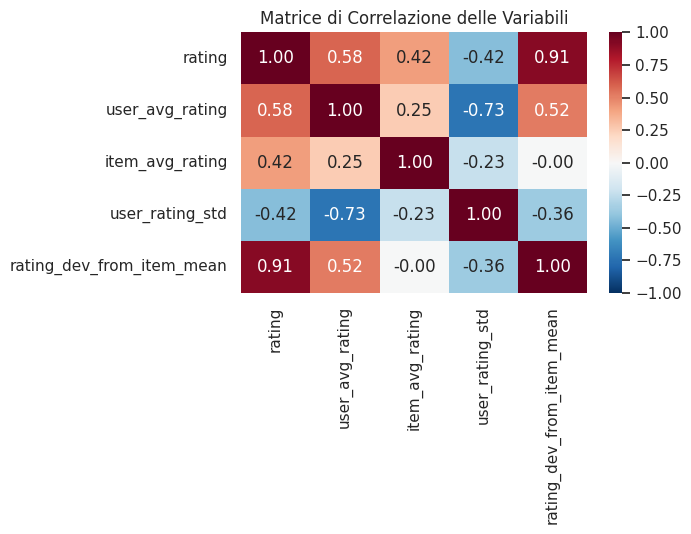

,rating,user_avg_rating,item_avg_rating,user_rating_std,rating_dev_from_item_mean
rating,1.000,0.581,0.417,-0.423,0.909
user_avg_rating,0.581,1.000,0.254,-0.727,0.523
item_avg_rating,0.417,0.254,1.000,-0.228,-0.000
user_rating_std,-0.423,-0.727,-0.228,1.000,-0.361
rating_dev_from_item_mean,0.909,0.523,-0.000,-0.361,1.000


In [41]:
# Feature derivate sulla matrice CF filtrata + correlazione
df_corr = df_cf.copy()
user_stats = df_cf.groupby("user_id")["rating"].agg(
    user_avg_rating="mean", user_rating_std="std"
).fillna(0)
item_stats = df_cf.groupby("item_id")["rating"].agg(
    item_avg_rating="mean"
)
df_corr = df_corr.join(user_stats, on="user_id").join(item_stats, on="item_id")
df_corr["rating_dev_from_item_mean"] = df_corr["rating"] - df_corr["item_avg_rating"]

corr_cols = ["rating", "user_avg_rating", "item_avg_rating", "user_rating_std", "rating_dev_from_item_mean"]
corr = df_corr[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice di Correlazione delle Variabili")
plt.tight_layout()
plt.show()
display(corr.round(3))

Tabella 1.6 — Statistiche matrice utente–prodotto dopo il filtraggio


,Parametro,Valore
0,Utenti,"2,611"
1,Prodotti,"1,500"
2,Rating osservati,"37,426"
3,Dimensione matrice,"3,916,500"
4,Densità,0.9556%
5,Sparsità,99.0444%


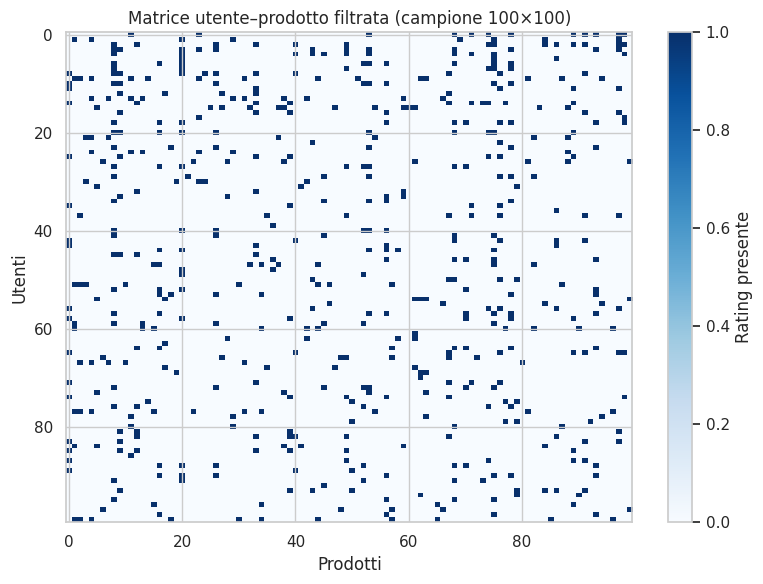

In [42]:
# Sezione 1.3.5 — Tabella riepilogativa matrice filtrata
n_u = df_cf["user_id"].nunique()
n_i = df_cf["item_id"].nunique()
n_r = len(df_cf)
dim = n_u * n_i
densita = n_r / dim

tab_filtrata = pd.DataFrame({
    "Parametro": ["Utenti", "Prodotti", "Rating osservati", "Dimensione matrice", "Densità", "Sparsità"],
    "Valore": [f"{n_u:,}", f"{n_i:,}", f"{n_r:,}", f"{dim:,}", f"{densita:.4%}", f"{1-densita:.4%}"]
})
print("Tabella 1.6 — Statistiche matrice utente–prodotto dopo il filtraggio")
display(tab_filtrata)

# Visualizzazione matrice filtrata (campione 100×100) per confronto con l'originale
top_u_f = df_cf.groupby("user_id").size().sort_values(ascending=False).head(100).index
top_i_f = df_cf.groupby("item_id").size().sort_values(ascending=False).head(100).index
samp_f = df_cf[df_cf["user_id"].isin(top_u_f) & df_cf["item_id"].isin(top_i_f)]
mat_f = samp_f.pivot_table(index="user_id", columns="item_id", values="rating", aggfunc="mean")
mat_f = mat_f.reindex(index=top_u_f, columns=top_i_f)

plt.figure(figsize=(8, 6))
plt.imshow(mat_f.notna(), aspect="auto", cmap="Blues", interpolation="nearest")
plt.title("Matrice utente–prodotto filtrata (campione 100×100)")
plt.xlabel("Prodotti"); plt.ylabel("Utenti")
plt.colorbar(label="Rating presente")
plt.tight_layout(); plt.show()

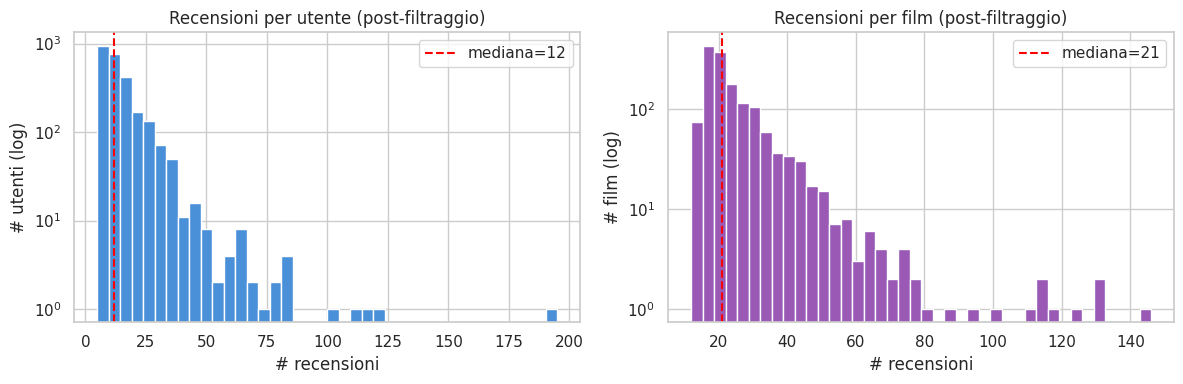

Distribuzione recensioni per UTENTE:


,Range,Count,%
0,5–9,951,36.4%
1,10–19,1177,45.1%
2,20–49,453,17.3%
3,50–99,25,1.0%
4,≥100,5,0.2%



Distribuzione recensioni per FILM:


,Range,Count,%
0,10–19,603,40.2%
1,20–49,838,55.9%
2,50–99,50,3.3%
3,100–199,9,0.6%
4,≥200,0,0.0%


In [43]:
# Distribuzione interazioni per utente e per film dopo il filtraggio
rpu = df_cf.groupby("user_id").size()
rpi = df_cf.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rpu, bins=40, color="#4A90D9")
axes[0].set_yscale("log")
axes[0].axvline(rpu.median(), color="red", linestyle="--", label=f"mediana={rpu.median():.0f}")
axes[0].set_title("Recensioni per utente (post-filtraggio)")
axes[0].set_xlabel("# recensioni"); axes[0].set_ylabel("# utenti (log)")
axes[0].legend()

axes[1].hist(rpi, bins=40, color="#9B59B6")
axes[1].set_yscale("log")
axes[1].axvline(rpi.median(), color="red", linestyle="--", label=f"mediana={rpi.median():.0f}")
axes[1].set_title("Recensioni per film (post-filtraggio)")
axes[1].set_xlabel("# recensioni"); axes[1].set_ylabel("# film (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabelle distribuzione (utile per il report)
def dist_table(s, ranges):
    rows = []
    for lo, hi in ranges:
        mask = (s >= lo) & (s <= hi) if hi else (s >= lo)
        label = f"{lo}–{hi}" if hi else f"≥{lo}"
        rows.append({"Range": label, "Count": mask.sum(), "%": f"{mask.mean()*100:.1f}%"})
    return pd.DataFrame(rows)

print("Distribuzione recensioni per UTENTE:")
display(dist_table(rpu, [(5,9),(10,19),(20,49),(50,99),(100,None)]))

print("\nDistribuzione recensioni per FILM:")
display(dist_table(rpi, [(10,19),(20,49),(50,99),(100,199),(200,None)]))

## 2.2 — Preparazione della Matrice Utente–Prodotto

Costruiamo la matrice sparsa utente×item in cui ogni cella contiene il rating (o resta vuota se l'interazione non esiste). Prima dividiamo i dati in **train (80%)** e **test (20%)**: il mapping da ID originali a indici interi viene definito **solo sul train**, così da simulare correttamente uno scenario reale ed evitare il **cold-start** (utenti o item presenti nel test ma mai visti nel train vengono scartati). Usiamo il formato sparso **CSR** per efficienza di memoria.

In [44]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix, csr_matrix
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# 2.2.2 Train-test split (80/20)
train_df, test_df = train_test_split(
    df_cf[["user_id", "item_id", "rating"]],
    test_size=0.20, random_state=RANDOM_STATE
)

# 2.2.3 Indicizzazione: mapping ID -> interi consecutivi, definito SUL TRAIN
user_ids = train_df["user_id"].unique()
item_ids = train_df["item_id"].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

# Rimuovi dal test gli utenti/item non visti nel train (cold-start)
n_test_before = len(test_df)
test_df = test_df[test_df["user_id"].isin(user2idx) & test_df["item_id"].isin(item2idx)]
print(f"Indicizzazione: utenti = 0..{len(user_ids)-1}, item = 0..{len(item_ids)-1}")
print(f"Righe test rimosse per cold-start: {n_test_before - len(test_df)}")

# 2.2.4 Costruzione matrice utente-prodotto (COO -> CSR)
rows = train_df["user_id"].map(user2idx).values
cols = train_df["item_id"].map(item2idx).values
vals = train_df["rating"].values
M = coo_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids))).tocsr()
print(f"Matrice utente-prodotto: {M.shape}, non-zero: {M.nnz}")

Indicizzazione: utenti = 0..2610, item = 0..1499
Righe test rimosse per cold-start: 0
Matrice utente-prodotto: (2611, 1500), non-zero: 29940


## 2.3 — Ricerca della Configurazione Ottimale del Modello K-NN

Usiamo **KNNBaseline** di Surprise, che calcola le componenti di baseline (media globale µ, bias utente bᵤ, bias item bᵢ) tramite **ALS**, e poi affina la predizione con i K vicini più simili pesati dalla similarità. Eseguiamo una grid search sulle combinazioni: similarità (cosine, pearson), shrinkage (10, 50, 100), modalità (user-based / item-based), e valori di K (5,10,20,30,40,60,80,100). Per ogni configurazione calcoliamo **RMSE** e **MSE** sul test set, e selezioniamo quella con errore minimo.

In [45]:
from surprise import Dataset, Reader, KNNBaseline, accuracy
import itertools

reader = Reader(rating_scale=(1, 5))

# Ricostruiamo train/test in formato Surprise mantenendo lo split gia fatto
trainset = Dataset.load_from_df(train_df[["user_id","item_id","rating"]], reader).build_full_trainset()
testset = list(test_df[["user_id","item_id","rating"]].itertuples(index=False, name=None))

# Griglia parametri (come nel report)
sim_names = ["cosine", "pearson"]
shrinkages = [10, 50, 100]
user_based_opts = [True, False]
k_values = [5, 10, 20, 30, 40, 60, 80, 100]

results = []
for sim_name, shrink, ub in itertools.product(sim_names, shrinkages, user_based_opts):
    for k in k_values:
        algo = KNNBaseline(
            k=k,
            sim_options={"name": sim_name, "user_based": ub, "shrinkage": shrink},
            bsl_options={"method": "als"},
            verbose=False
        )
        algo.fit(trainset)
        preds = algo.test(testset)
        rmse = accuracy.rmse(preds, verbose=False)
        mse = rmse ** 2
        results.append({
            "similarita": sim_name, "shrinkage": shrink,
            "modalita": "user-based" if ub else "item-based",
            "k": k, "RMSE": rmse, "MSE": mse
        })

res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("Top 10 configurazioni per RMSE:")
display(res_df.head(10))

Top 10 configurazioni per RMSE:


,similarita,shrinkage,modalita,k,RMSE,MSE
0,cosine,10,item-based,100,0.984160,0.968571
1,cosine,50,item-based,100,0.984160,0.968571
2,cosine,100,item-based,100,0.984160,0.968571
3,cosine,50,item-based,80,0.984166,0.968582
4,cosine,100,item-based,80,0.984166,0.968582
5,cosine,10,item-based,80,0.984166,0.968582
6,cosine,10,item-based,60,0.984168,0.968587
7,cosine,50,item-based,60,0.984168,0.968587
8,cosine,100,item-based,60,0.984168,0.968587
9,cosine,100,item-based,40,0.984175,0.968600


### 2.3.3 — Risultati sperimentali

Visualizziamo l'andamento dell'RMSE al variare di K, separato per ciascuna combinazione di similarità e modalità, per capire dove si trova il minimo e come si comporta il modello.

=== CONFIGURAZIONE OTTIMALE ===
Similarita: cosine | Shrinkage: 10 | Modalita: item-based | k: 100
RMSE = 0.98416 | MSE = 0.96857


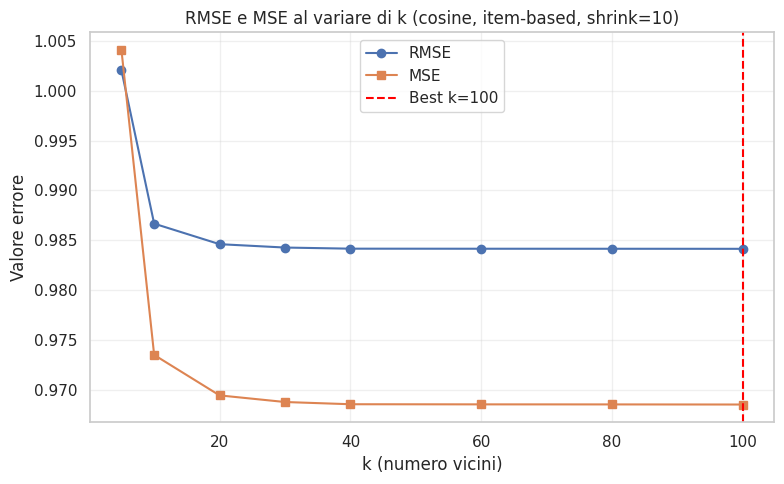

In [46]:
import matplotlib.pyplot as plt

best = res_df.iloc[0]
print("=== CONFIGURAZIONE OTTIMALE ===")
print(f"Similarita: {best['similarita']} | Shrinkage: {best['shrinkage']} | "
      f"Modalita: {best['modalita']} | k: {best['k']}")
print(f"RMSE = {best['RMSE']:.5f} | MSE = {best['MSE']:.5f}")

# Grafico RMSE vs k per la configurazione vincente (fissando similarita+shrinkage+modalita)
mask = ((res_df["similarita"]==best["similarita"]) &
        (res_df["shrinkage"]==best["shrinkage"]) &
        (res_df["modalita"]==best["modalita"]))
sub = res_df[mask].sort_values("k")

plt.figure(figsize=(8,5))
plt.plot(sub["k"], sub["RMSE"], marker="o", label="RMSE")
plt.plot(sub["k"], sub["MSE"], marker="s", label="MSE")
plt.axvline(best["k"], color="red", linestyle="--", label=f"Best k={best['k']}")
plt.xlabel("k (numero vicini)"); plt.ylabel("Valore errore")
plt.title(f"RMSE e MSE al variare di k ({best['similarita']}, {best['modalita']}, shrink={best['shrinkage']})")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 2.4 — Filling della Matrice di Rating

Usando la configurazione ottimale, riaddestriamo il modello su tutto il dataset e prediciamo **tutti** i rating mancanti (le coppie utente-item non osservate). Otteniamo così una matrice densa, dove ogni cella ha un valore (osservato o predetto), pronta per il clustering e le raccomandazioni.

In [47]:
import time

print("[1/4] Riaddestramento modello su intero df_cf...")
t0 = time.time()
full_data = Dataset.load_from_df(df_cf[["user_id","item_id","rating"]], reader)
full_trainset = full_data.build_full_trainset()
best_algo = KNNBaseline(
    k=int(best["k"]),
    sim_options={"name": best["similarita"],
                 "user_based": best["modalita"]=="user-based",
                 "shrinkage": int(best["shrinkage"])},
    bsl_options={"method": "als"}, verbose=True)
best_algo.fit(full_trainset)
print(f"   fit in {time.time()-t0:.1f}s")

print("[2/4] Costruzione anti-testset (coppie mancanti)...")
t0 = time.time()
anti = full_trainset.build_anti_testset()
print(f"   {len(anti):,} coppie in {time.time()-t0:.1f}s")

print(f"[3/4] Predizione di {len(anti):,} coppie (lento, KNN per-coppia)...")
t0 = time.time()
pred_missing = best_algo.test(anti)
dt = time.time()-t0
print(f"   predette in {dt:.1f}s ({len(anti)/max(dt,1e-9):,.0f} pred/s)")

print("[4/4] Assemblaggio matrice densa (numpy, vettorizzato)...")
t0 = time.time()
all_users = df_cf["user_id"].unique()
all_items = df_cf["item_id"].unique()
u_idx = {u: i for i, u in enumerate(all_users)}
i_idx = {it: j for j, it in enumerate(all_items)}

M = np.full((len(all_users), len(all_items)), np.nan, dtype=np.float32)
M[df_cf["user_id"].map(u_idx).to_numpy(),
  df_cf["item_id"].map(i_idx).to_numpy()] = df_cf["rating"].to_numpy(np.float32)

n = len(pred_missing)
pu = np.fromiter((u_idx[p.uid] for p in pred_missing), np.int32, n)
pi = np.fromiter((i_idx[p.iid] for p in pred_missing), np.int32, n)
pe = np.fromiter((p.est       for p in pred_missing), np.float32, n)
M[pu, pi] = pe

rating_matrix = pd.DataFrame(M, index=all_users, columns=all_items)
print(f"   matrice densa {rating_matrix.shape} in {time.time()-t0:.1f}s, valori predetti: {n:,}")


[1/4] Riaddestramento modello su intero df_cf...
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
   fit in 0.5s
[2/4] Costruzione anti-testset (coppie mancanti)...
   3,879,074 coppie in 2.3s
[3/4] Predizione di 3,879,074 coppie (lento, KNN per-coppia)...
   predette in 107.0s (36,251 pred/s)
[4/4] Assemblaggio matrice densa (numpy, vettorizzato)...
   matrice densa (2611, 1500) in 1.8s, valori predetti: 3,879,074


## 2.5 — Segmentazione degli Utenti (Clustering)

Ogni utente è ora un vettore di rating (una riga della matrice densa). Riduciamo la dimensionalità con **PCA** (20 componenti per il clustering, 2 per la visualizzazione). Poi applichiamo **K-Means**: per usare la cosine similarity normalizziamo i vettori a norma L2 (su vettori normalizzati la distanza euclidea è equivalente alla cosine). Scegliamo il numero di cluster k con **Elbow Method** (inertia) e **Silhouette Score**.

Varianza spiegata da PC1+PC2: 0.58991766


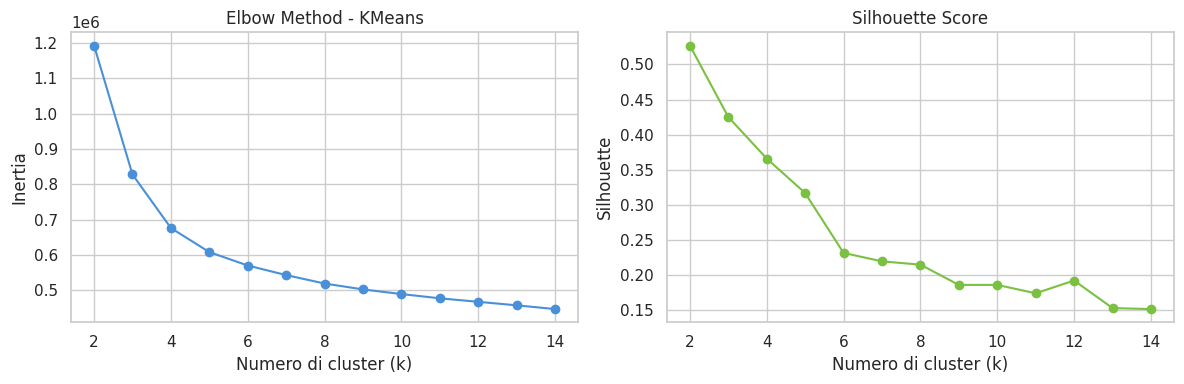

In [48]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# 2.5.1 Preprocessing + PCA
X = rating_matrix.fillna(rating_matrix.mean()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # standardizza per colonna (per film)

pca20 = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca = pca20.fit_transform(X_scaled)

# ricontrolla la varianza spiegata
pca_check = PCA().fit(X_scaled)
print("Varianza spiegata da PC1+PC2:", pca_check.explained_variance_ratio_[:2].sum())

# 2.5.2 Scelta di k: Elbow + Silhouette
K_range = range(2, 15)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(list(K_range), inertias, marker="o", color="#4A90D9")
ax[0].set_title("Elbow Method - KMeans"); ax[0].set_xlabel("Numero di cluster (k)"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_range), silhouettes, marker="o", color="#7AC142")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("Numero di cluster (k)"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

### 2.5.3 — Clustering finale

Scelto il k ottimale (in base ai due criteri sopra), eseguiamo il K-Means definitivo e profiliamo ogni cluster: numero di utenti, rating medio, recensioni medie per utente. Questo permette di interpretare i segmenti (utenti positivi, equilibrati, critici).

In [49]:
# Imposta best_k_clusters in base ai grafici sopra : i grafici rappresentano il piu grande tradeoff a k = 2
best_k_clusters = 2

km = KMeans(n_clusters=best_k_clusters, init="k-means++", n_init=10, random_state=RANDOM_STATE)
user_clusters = pd.Series(km.fit_predict(X_pca), index=rating_matrix.index, name="cluster")

# Profilazione dei cluster
recensioni_per_user = df_cf.groupby("user_id").size()
prof = pd.DataFrame({
    "cluster": user_clusters,
    "rating_medio": rating_matrix.mean(axis=1),
    "recensioni": recensioni_per_user.reindex(rating_matrix.index)
})
summary = prof.groupby("cluster").agg(
    n_utenti=("rating_medio", "size"),
    rating_medio=("rating_medio", "mean"),
    recensioni_per_user=("recensioni", "mean")
).round(2)
print("Statistiche dei cluster individuati:")
display(summary)

Statistiche dei cluster individuati:


,n_utenti,rating_medio,recensioni_per_user
cluster,,,
0,1887,4.48,14.04
1,724,3.52,15.10


### 2.5.4 — Visualizzazione cluster

Proiettiamo gli utenti nello spazio delle prime 2 componenti principali, colorando per cluster, per vedere la separazione dei segmenti.

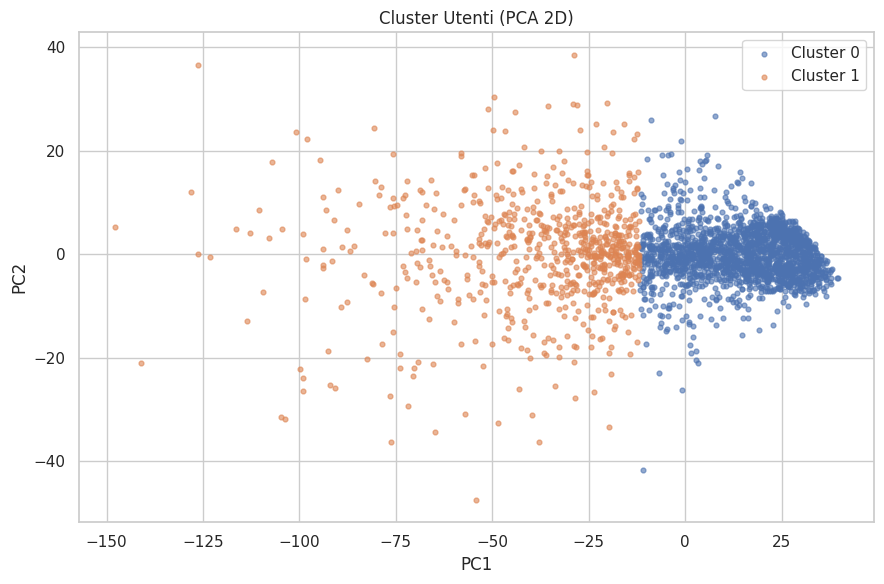

In [50]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
for c in range(best_k_clusters):
    mask = user_clusters.values == c
    plt.scatter(X_2d[mask,0], X_2d[mask,1], s=12, alpha=0.6, label=f"Cluster {c}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Cluster Utenti (PCA 2D)")
plt.legend(); plt.tight_layout(); plt.show()

## 2.6 — Generazione delle Raccomandazioni Top-N

Per ogni utente ordiniamo gli item **non ancora valutati** in base al rating predetto, e prendiamo i primi N. Mostriamo poi le raccomandazioni per un utente rappresentativo di ciascun cluster, per osservare come i segmenti ricevano suggerimenti coerenti col loro profilo.

In [51]:
TOP_N = 10
rated_by_user = df_cf.groupby("user_id")["item_id"].agg(set).to_dict()

def top_n_for_user(user, n=TOP_N):
    seen = rated_by_user.get(user, set())
    row = rating_matrix.loc[user]
    candidates = row[~row.index.isin(seen)].sort_values(ascending=False)
    return candidates.head(n)

# Un utente rappresentativo per cluster (il primo di ciascun gruppo)
print("Top-N raccomandazioni per un utente rappresentativo di ogni cluster:\n")
for c in range(best_k_clusters):
    rep_user = user_clusters[user_clusters==c].index[0]
    recs = top_n_for_user(rep_user)
    print(f"--- Cluster {c} | utente {rep_user} | rating medio predetto: {recs.mean():.2f} ---")
    for item, est in recs.items():
        print(f"    {item}  ->  {est:.2f}")
    print()

Top-N raccomandazioni per un utente rappresentativo di ogni cluster:

--- Cluster 0 | utente AGMOD6CPJKWFVVFKCIMT5LDJ4PXA | rating medio predetto: 5.00 ---
    B00000K3D4  ->  5.00
    B0B18G8R9B  ->  5.00
    B08DGXHQMH  ->  5.00
    6305428042  ->  5.00
    B00XVPL8G6  ->  5.00
    B00XVQLNDI  ->  5.00
    B00S1VFB36  ->  5.00
    B00V4JGNV6  ->  5.00
    B00VFTA70I  ->  5.00
    B00HLTD8RA  ->  5.00

--- Cluster 1 | utente AGGVPVQLIVT6AFKNZAE7OI6BSSIA | rating medio predetto: 5.00 ---
    B00H7NEXYC  ->  5.00
    B002HK9IDQ  ->  5.00
    B0785YHVXM  ->  5.00
    B018HIZSIA  ->  5.00
    B006Z48TZS  ->  5.00
    B000JQYE34  ->  5.00
    B00AKIPAG6  ->  5.00
    B00N1JQ3RQ  ->  5.00
    B00NYC73JW  ->  5.00
    B00RT7K67E  ->  5.00



## 2.7 — Matrix Factorization (SVD) e Confronto Finale

Applichiamo un secondo approccio: la decomposizione **SVD**, che approssima la matrice con k fattori latenti, catturando strutture nascoste nelle preferenze. Confrontiamo SVD col miglior KNNBaseline in termini di RMSE/MSE, usando lo stesso train/test split per un confronto equo.

Confronto KNNBaseline vs SVD:


,Modello,RMSE,MSE
0,KNNBaseline (ottimizzato),0.9842,0.9686
1,SVD (50 fattori latenti),0.9459,0.8947


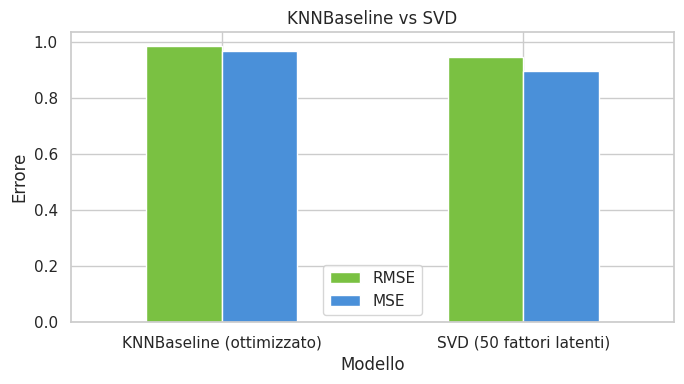

Variazione RMSE di SVD rispetto a KNNBaseline: +3.9%


In [52]:
from surprise import SVD

# SVD addestrato sullo stesso trainset, valutato sullo stesso testset
svd = SVD(n_factors=50, random_state=RANDOM_STATE)
svd.fit(trainset)
svd_preds = svd.test(testset)
svd_rmse = accuracy.rmse(svd_preds, verbose=False)
svd_mse = svd_rmse ** 2

confronto = pd.DataFrame({
    "Modello": ["KNNBaseline (ottimizzato)", "SVD (50 fattori latenti)"],
    "RMSE": [best["RMSE"], svd_rmse],
    "MSE": [best["MSE"], svd_mse]
}).round(4)
print("Confronto KNNBaseline vs SVD:")
display(confronto)

ax = confronto.set_index("Modello")[["RMSE","MSE"]].plot(
    kind="bar", figsize=(7,4), color=["#7AC142","#4A90D9"], rot=0)
ax.set_ylabel("Errore"); ax.set_title("KNNBaseline vs SVD")
plt.tight_layout(); plt.show()

miglioramento = (best["RMSE"] - svd_rmse) / best["RMSE"] * 100
print(f"Variazione RMSE di SVD rispetto a KNNBaseline: {miglioramento:+.1f}%")

### 2.7.3 — Analisi delle raccomandazioni

Confrontiamo qualitativamente le Top-10 dei due modelli per un utente campione: misuriamo l'**overlap** (quanti item in comune) e la **dispersione** dei punteggi predetti, per capire se SVD produce raccomandazioni più diversificate rispetto al KNN.

In [53]:
# Costruisci la matrice densa anche per SVD per confronto Top-N
sample_user = rating_matrix.index[0]

# Top-N da KNN (gia in rating_matrix)
knn_top = set(top_n_for_user(sample_user).index)

# Top-N da SVD: predici gli item non visti per sample_user
seen = rated_by_user.get(sample_user, set())
svd_scores = {it: svd.predict(sample_user, it).est for it in all_items if it not in seen}
svd_top_series = pd.Series(svd_scores).sort_values(ascending=False).head(TOP_N)
svd_top = set(svd_top_series.index)

overlap = len(knn_top & svd_top)
print(f"Utente campione: {sample_user}")
print(f"Overlap Top-{TOP_N} tra KNN e SVD: {overlap}/{TOP_N} item in comune")
print(f"Dispersione punteggi KNN (std): {top_n_for_user(sample_user).std():.3f}")
print(f"Dispersione punteggi SVD (std): {svd_top_series.std():.3f}")


# Quanto sono "appiattiti" i rating predetti?
print(rating_matrix.values.flatten())
print("Media:", rating_matrix.values.mean())
print("Std:", rating_matrix.values.std())
print("% di valori >= 4.9:", (rating_matrix.values >= 4.9).mean() * 100, "%")

Utente campione: AGGVPVQLIVT6AFKNZAE7OI6BSSIA
Overlap Top-10 tra KNN e SVD: 0/10 item in comune
Dispersione punteggi KNN (std): 0.000
Dispersione punteggi SVD (std): 0.032
[3.        4.2552238 3.1586626 ... 4.49777   4.912245  3.9635758]
Media: 4.2137966
Std: 0.75996315
% di valori >= 4.9: 19.04662326056428 %


## 2.8 — Conclusioni

Riepilogo dei risultati: la configurazione KNN ottimale trovata, il confronto con SVD, i punti di forza (semplicità, interpretabilità) e i limiti del CF (sensibilità alla sparsità, cold-start, assenza di informazione sul contenuto — che motiva il passaggio al **Content-Based** del capitolo successivo).

In [54]:
print("="*55)
print("RIEPILOGO COLLABORATIVE FILTERING")
print("="*55)
print(f"KNN ottimale: {best['similarita']}, {best['modalita']}, "
      f"shrink={best['shrinkage']}, k={best['k']}")
print(f"  RMSE = {best['RMSE']:.4f} | MSE = {best['MSE']:.4f}")
print(f"SVD (50 fattori): RMSE = {svd_rmse:.4f} | MSE = {svd_mse:.4f}")
print(f"Numero cluster utenti: {best_k_clusters}")
print(f"Modello migliore: {'SVD' if svd_rmse < best['RMSE'] else 'KNNBaseline'}")
print("="*55)

RIEPILOGO COLLABORATIVE FILTERING
KNN ottimale: cosine, item-based, shrink=10, k=100
  RMSE = 0.9842 | MSE = 0.9686
SVD (50 fattori): RMSE = 0.9459 | MSE = 0.8947
Numero cluster utenti: 2
Modello migliore: SVD


---
# PARTE 2 — Livello Intermedio: Sistema di Raccomandazione Content-Based

## 3.0 — Obiettivi e impostazione

Il Collaborative Filtering (Parte 1) ignora il *contenuto* dei film e sfrutta solo le co-occorrenze di rating. Qui costruiamo un sistema **content-based**: ogni film e' rappresentato dai suoi attributi testuali (`title` + `description`) e i rating sono predetti per analogia di contenuto.

Passi (consegna livello intermedio):
1. **Preprocessing NLP** dei campi testuali (3.1)
2. **Embedding** con tecnica frequenziale **TF-IDF** (3.2) e tecnica neurale **transformer** `all-MiniLM-L6-v2` (3.3)
3. **Predizione dei rating con K-NN** per ogni utente usando entrambi gli embedding (3.4)
4. **Valutazione critica** TF-IDF vs transformer (3.5)
5. **Valutazione critica** Content-Based vs Collaborative Filtering (3.6)

Usiamo lo **stesso split train/test** del CF (`train_df` / `test_df`): RMSE e MSE sono cosi' direttamente confrontabili.

In [55]:
# === PARTE 2 — Caricamento dei metadati testuali (self-contained) ===
# Sezione indipendente dalla 1.4: se 'meta' esiste gia lo riusa, altrimenti carica.
from datasets import load_dataset

try:
    meta
except NameError:
    import json, fsspec
    def load_meta(category, streaming=True, max_rows=None):
        # Lettura riga-per-riga: evita l'inferenza di schema di pyarrow che fallisce
        # quando un campo annidato (es. details.Producers) cambia tipo (array -> string).
        url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_{category}.jsonl"
        rows = []
        with fsspec.open(url, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
                if max_rows and len(rows) >= max_rows:
                    break
        return pd.DataFrame(rows)
    meta = load_meta(CATEGORY)
    print("Metadata caricati:", meta.shape)

def _join_list(x):
    if isinstance(x, (list, np.ndarray)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)

# Campo testuale = title + description (i campi richiesti dalla consegna)
meta["title_str"] = meta["title"].fillna("").astype(str)
meta["desc_str"]  = meta["description"].apply(_join_list)
meta["text_raw"]  = (meta["title_str"].str.strip() + ". " + meta["desc_str"].str.strip()).str.strip()

# Tieni solo i prodotti presenti nelle review filtrate (df_cf) e con testo non vuoto
items_cf = set(df_cf["item_id"])
cb = (meta[meta["parent_asin"].isin(items_cf)]
        .drop_duplicates("parent_asin")
        .copy())
cb = cb[cb["text_raw"].str.split().apply(len) > 0].reset_index(drop=True)

# Mapping item_id -> riga nelle matrici di embedding
pos = {asin: i for i, asin in enumerate(cb["parent_asin"])}
print(f"Item con testo usabile: {len(cb):,} su {len(items_cf):,} item del CF "
      f"({len(cb)/len(items_cf):.1%} di copertura)")

Failed to load JSON from file 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_Movies_and_TV.jsonl' with error <class 'pyarrow.lib.ArrowInvalid'>: JSON parse error: Column(/details/Producers) changed from array to string in row 9
ERROR:datasets.packaged_modules.json.json:Failed to load JSON from file 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_Movies_and_TV.jsonl' with error <class 'pyarrow.lib.ArrowInvalid'>: JSON parse error: Column(/details/Producers) changed from array to string in row 9


ArrowInvalid: JSON parse error: Column(/details/Producers) changed from array to string in row 9

## 3.1 — Preprocessing dei campi testuali

Pipeline NLP vista in laboratorio: minuscolo, tokenizzazione, rimozione di punteggiatura/numeri e stopword, **stemming** (Porter). Il testo pulito alimenta il TF-IDF; il transformer riceve invece il **testo grezzo**, perche' e' pre-addestrato su linguaggio naturale e perderebbe informazione su token stemmati.

In [ ]:
# === 3.1 — Preprocessing NLP (tecniche viste in laboratorio) ===
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)

STOP = set(stopwords.words("english"))
stemmer = PorterStemmer()
_token_re = re.compile(r"[a-z]+")

def preprocess(text):
    tokens = _token_re.findall(text.lower())               # solo lettere, minuscolo
    tokens = [t for t in tokens if t not in STOP and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

cb["text_clean"] = cb["text_raw"].apply(preprocess)

# Esempio prima/dopo
ex = cb.iloc[0]
print("RAW   :", ex["text_raw"][:200])
print("CLEAN :", ex["text_clean"][:200])

## 3.2 — Embedding frequenziale (TF-IDF)

Rappresentazione sparsa basata sulla frequenza dei termini pesata per la rarita' nel corpus (`idf`). Usiamo unigrammi + bigrammi, `min_df=2` per scartare termini rari/rumore e un cap a 5000 feature. Le righe sono L2-normalizzate, quindi il prodotto scalare equivale alla **similarita' coseno**.

In [ ]:
# === 3.2 — Embedding frequenziale: TF-IDF ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(cb["text_clean"])     # (n_item, V) sparsa
X_tfidf = normalize(X_tfidf, norm="l2")             # cosine = prodotto scalare
print("Matrice TF-IDF:", X_tfidf.shape, "| dim. vocabolario:", len(tfidf.vocabulary_))

## 3.3 — Embedding neurale (transformer)

`all-MiniLM-L6-v2` (Sentence-Transformers) mappa ogni testo in un vettore **denso di 384 dimensioni** che cattura la semantica (sinonimi, contesto), non la semplice sovrapposizione di parole. Gli embedding sono gia' L2-normalizzati in uscita.

In [ ]:
# === 3.3 — Embedding neurale: transformer (all-MiniLM-L6-v2) ===
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-L6-v2")   # 384 dim, usa GPU se disponibile
X_bert = st_model.encode(
    cb["text_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,        # output gia L2-normalizzato -> cosine
)
X_bert = np.asarray(X_bert, dtype=np.float32)
print("Matrice transformer:", X_bert.shape)

## 3.4 — Predizione dei rating con K-NN

Per ogni coppia (utente *u*, film *i*) del test:
- recuperiamo i film che *u* ha valutato nel **train**;
- calcoliamo la similarita' coseno tra l'embedding di *i* e quelli dei film visti;
- prediciamo il rating come media dei rating dei **K=20 film piu' simili**, pesata dalla similarita':

$$\hat{r}(u,i) = \frac{\sum_{j \in N_k(i)\,\cap\,visti(u)} sim(i,j)\cdot r_{uj}}{\sum_j sim(i,j)}$$

Se l'utente non ha vicini utili, fallback alla sua media (o alla media globale). Le predizioni sono clippate nell'intervallo dei rating.

In [ ]:
# === 3.4 — Predizione dei rating con K-NN content-based ===
from scipy.sparse import issparse

LO, HI = RATING_SCALE

def _build_profiles(train_df, pos):
    """user_id -> (indici item, rating) sui soli item con testo."""
    prof = {}
    sub = train_df[train_df["item_id"].isin(pos)]
    for u, it, r in sub[["user_id", "item_id", "rating"]].itertuples(index=False):
        prof.setdefault(u, ([], []))
        prof[u][0].append(pos[it]); prof[u][1].append(r)
    return {u: (np.array(a), np.array(b, dtype=float)) for u, (a, b) in prof.items()}

def content_knn_predict(E, train_df, test_df, pos, k=20):
    mu = train_df["rating"].mean()
    prof = _build_profiles(train_df, pos)
    test_cb = test_df[test_df["item_id"].isin(pos)]
    preds, trues = [], []
    for u, grp in test_cb.groupby("user_id"):
        true_r = grp["rating"].values
        if u not in prof:                        # utente senza storico testuale
            preds.extend([mu] * len(grp)); trues.extend(true_r); continue
        idx, rat = prof[u]
        tgt = grp["item_id"].map(pos).values
        Er, Et = E[idx], E[tgt]
        sims = Et @ Er.T
        sims = sims.toarray() if issparse(sims) else np.asarray(sims)
        for row, tr in zip(sims, true_r):
            order = np.argsort(-row)[:k]
            w = row[order]; m = w > 0
            if m.sum() == 0:
                preds.append(rat.mean())         # fallback: media utente
            else:
                preds.append(float(np.dot(w[m], rat[order][m]) / w[m].sum()))
            trues.append(tr)
    preds = np.clip(preds, LO, HI)
    return np.array(preds), np.array(trues)

def rmse_mse(pred, true):
    mse = float(np.mean((pred - true) ** 2))
    return mse ** 0.5, mse

K_CB = 20
p_tf, y   = content_knn_predict(X_tfidf, train_df, test_df, pos, k=K_CB)
p_be, _   = content_knn_predict(X_bert,  train_df, test_df, pos, k=K_CB)

rmse_tf, mse_tf = rmse_mse(p_tf, y)
rmse_be, mse_be = rmse_mse(p_be, y)
print(f"Coppie di test valutate: {len(y):,} (su {len(test_df):,} del test set CF)")
print(f"TF-IDF      : RMSE = {rmse_tf:.4f} | MSE = {mse_tf:.4f}")
print(f"Transformer : RMSE = {rmse_be:.4f} | MSE = {mse_be:.4f}")

## 3.5 — Valutazione critica: TF-IDF vs Transformer

Confronto delle due tecniche di embedding sullo stesso K-NN e sullo stesso test set.

**Da commentare nel report** (in base ai numeri ottenuti):
- **Accuratezza**: quale tecnica ottiene RMSE/MSE minore.
- **Qualita' dei vicini**: il TF-IDF lega film che *condividono parole* (stessa saga, franchise, termini del titolo); il transformer coglie similarita' **semantiche** anche senza parole in comune (genere, tema, tono) — visibile nel controllo qualitativo sotto.
- **Costi**: TF-IDF e' leggero e interpretabile (si vedono i termini); il transformer e' piu' pesante (modello + GPU) ma piu' robusto a sinonimi, descrizioni brevi/assenti e rumore lessicale.

In [ ]:
# === 3.5 — Confronto TF-IDF vs Transformer ===
res_cb = pd.DataFrame({
    "Tecnica": ["TF-IDF (frequenziale)", "all-MiniLM-L6-v2 (neurale)"],
    "RMSE": [rmse_tf, rmse_be],
    "MSE":  [mse_tf, mse_be],
})
display(res_cb)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(res_cb["Tecnica"], res_cb["RMSE"], color=["steelblue", "indianred"])
ax.set_ylabel("RMSE (test)"); ax.set_title("Content-Based: TF-IDF vs Transformer")
for i, v in enumerate(res_cb["RMSE"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

# Controllo qualitativo: film piu simili a un titolo campione
def most_similar(E, seed=0, n=5):
    row = E[seed] @ E.T
    row = row.toarray().ravel() if issparse(row) else np.asarray(row).ravel()
    order = np.argsort(-row)[1:n+1]              # esclude se stesso
    return cb.iloc[order][["title_str"]].assign(sim=row[order].round(3))

seed = 0
print("FILM SEED:", cb.iloc[seed]["title_str"][:80])
print("\n--- Vicini TF-IDF ---");     display(most_similar(X_tfidf, seed))
print("--- Vicini Transformer ---");    display(most_similar(X_bert, seed))

## 3.6 — Valutazione critica: Content-Based vs Collaborative Filtering

Confronto sui medesimi train/test set.

**Da commentare nel report:**
- **Accuratezza** (tabella sotto): il CF (KNNBaseline/SVD) modella i bias utente/item e tende a un RMSE piu' basso su utenti con storico ricco; il content-based di norma e' meno preciso sul rating puntuale.
- **Cold-start**: il content-based raccomanda film **nuovi o di coda lunga** mai valutati (basta il testo), dove il CF fallisce per mancanza di co-rating.
- **Copertura**: dipende dalla disponibilita' dei metadati (vedi % copertura in 3.0); il CF copre solo item con sufficienti interazioni.
- **Interpretabilita' & serendipita'**: il content-based spiega le raccomandazioni ("simile per trama/genere") ma rischia l'over-specializzazione (poca varieta'); il CF favorisce la scoperta tramite utenti simili.

**Conclusione**: i due approcci sono **complementari** — un sistema ibrido (CF + content-based) unisce accuratezza sugli utenti attivi e copertura sul cold-start.

In [ ]:
# === 3.6 — Confronto finale: Collaborative Filtering vs Content-Based ===
best_cb_rmse = min(rmse_tf, rmse_be)
best_cb_name = "TF-IDF" if rmse_tf <= rmse_be else "Transformer"

confronto = pd.DataFrame({
    "Sistema": ["CF — KNNBaseline", "CF — SVD", f"Content-Based — {best_cb_name}"],
    "RMSE": [best["RMSE"], svd_rmse, best_cb_rmse],
})
print("="*55)
print("CONFRONTO COLLABORATIVE FILTERING vs CONTENT-BASED")
print("="*55)
display(confronto.sort_values("RMSE").reset_index(drop=True))

## Sezione 1.4 — Analisi del dataset Metadata

In [ ]:
# === SEZIONE 1.4 — ANALISI DATASET METADATA ===
def load_meta(category, streaming=True, max_rows=None):
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=streaming)
    rows = []
    for ex in ds:
        rows.append(ex)
        if max_rows and len(rows) >= max_rows:
            break
    return pd.DataFrame(rows)

meta = load_meta(CATEGORY)
print("Metadata shape:", meta.shape)
print("Campi disponibili:", list(meta.columns))

In [ ]:
# Sezione 1.4.2 — Qualità dei dati: percentuale valori mancanti per campo
def pct_missing(col):
    s = meta[col]
    if s.apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        # campo lista: vuoto = lista vuota
        return s.apply(lambda x: len(x) == 0 if isinstance(x, (list, np.ndarray)) else pd.isna(x)).mean()
    return s.isna().mean()

quality = pd.DataFrame({
    "Campo": meta.columns,
    "% Mancanti": [f"{pct_missing(c)*100:.2f}%" for c in meta.columns]
})
print("Tabella 1.x — Qualità dei dati (valori mancanti per campo)")
display(quality.sort_values("% Mancanti", ascending=False))

In [ ]:
# Sezione 1.4.3 — Analisi componenti testuali
def join_list(x):
    if isinstance(x, (list, np.ndarray)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)

meta["title_str"] = meta["title"].fillna("").astype(str)
meta["desc_str"] = meta["description"].apply(join_list)

meta["title_len"] = meta["title_str"].str.split().apply(len)
meta["desc_len"] = meta["desc_str"].str.split().apply(len)

pct_desc_vuote = (meta["desc_len"] == 0).mean()

print("Titoli:")
print(f"  lunghezza media: {meta['title_len'].mean():.1f} parole | mediana: {meta['title_len'].median():.0f}")
print("\nDescrizioni:")
print(f"  lunghezza media: {meta['desc_len'].mean():.1f} parole | mediana: {meta['desc_len'].median():.0f}")
print(f"  descrizioni vuote: {pct_desc_vuote:.2%}")

# Grafici distribuzione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(meta["title_len"], bins=40, color="steelblue")
axes[0].set_title("Distribuzione lunghezza titoli")
axes[0].set_xlabel("Numero parole"); axes[0].set_ylabel("Frequenza")
axes[1].hist(meta["desc_len"], bins=40, color="indianred")
axes[1].set_title("Distribuzione lunghezza descrizioni")
axes[1].set_xlabel("Numero parole"); axes[1].set_ylabel("Frequenza")
plt.tight_layout(); plt.show()

In [ ]:
# Sezione 1.4.4 — Riduzione ai prodotti presenti nelle review filtrate
item_filtrati = set(df_cf["item_id"])
n_meta_orig = len(meta)
metadata_subset = meta[meta["parent_asin"].isin(item_filtrati)].copy()

print(f"Prodotti nel metadata originale: {n_meta_orig:,}")
print(f"Prodotti nel metadata_subset (intersezione con review): {len(metadata_subset):,}")
print(f"Prodotti persi: {n_meta_orig - len(metadata_subset):,}")

print("\nStatistiche testuali del subset:")
print(f"  lunghezza media titoli: {metadata_subset['title_len'].mean():.1f} parole")
print(f"  descrizioni vuote: {(metadata_subset['desc_len']==0).mean():.2%}")
print(f"  lunghezza media descrizioni: {metadata_subset['desc_len'].mean():.1f} parole")

# Scatter titolo vs descrizione (come Figura 1.3c del report)
plt.figure(figsize=(7, 5))
plt.scatter(metadata_subset["title_len"], metadata_subset["desc_len"], alpha=0.4, color="indianred")
plt.title("Titolo vs Descrizione (lunghezza in parole)")
plt.xlabel("Lunghezza titolo"); plt.ylabel("Lunghezza descrizione")
plt.tight_layout(); plt.show()

## Conclusioni Progetto Base

Sintesi da riportare nel report (riempire con i tuoi numeri):

- **Dataset / EDA:** sparsita, sbilanciamento verso rating alti, long-tail di utenti/item, correlazioni deboli tra rating e helpful_vote / lunghezza testo.
- **K-NN ottimale:** indica metrica di similarita, K e user/item based vincenti + RMSE/MSE.
- **Clustering:** numero di segmenti scelto (Elbow/Silhouette) e descrizione qualitativa dei cluster.
- **Top-N:** esempio di lista raccomandata.
- **K-NN vs Matrix Factorization:** quale generalizza meglio e perche (la MF tende a gestire meglio la sparsita catturando fattori latenti).

> Prossimi notebook: **Intermedio** (content-based con TF-IDF e transformers) e **Avanzato** (sentiment analysis).